In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from joblib import load, dump
import geopandas as gpd
from esda.moran import Moran
from libpysal.weights import lat2W, DistanceBand
from scipy.spatial.distance import cdist, pdist
from scipy.stats import kendalltau
from xicorrelation import xicorr
import dcor
from tqdm import tqdm
import os
import warnings
cwd=os.getcwd()
# cwd='G:/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code'
cwd = '/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code'
print(cwd)

/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code


# Utils

In [7]:
def flatten_dict(d: dict):
    """
    Flattens a nested dictionary.
    """
    out = {}
    for k, v in d.items():
        if isinstance(v, np.ndarray):
            if v.ndim == 0:
                out[k] = v.item()
            else:
                out[k] = v.tolist()
        else:
            out[k] = v
    return out

def get_visit_prob(sims: list):
    visit_flag_list = []
    num_sims = len(sims)
    for i in range(num_sims):
        df = sims[i]
        visit_flag = np.isin(df['state'], ['C', 'I']).astype(int)
        visit_flag_list.append(visit_flag)
    
    visit_count = np.sum(visit_flag_list, axis=0)
    visit_prob = visit_count / num_sims
    return visit_prob

In [13]:
folder='8area_run0_nsite10_sfreq52'

dir_metric = os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_metric')    ##sites=10
dir_metric

'/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana05_opt_3area2road/8area_run0_nsite10_sfreq52/output_metric'

In [14]:
dir_studyarea=os.path.join(cwd, 'study_area')

"""Read distributions"""
distr_list = [
    load(os.path.join(dir_studyarea,f'host_distributions/area0{i}.joblib')) for i in range(1,9)
]
print(len(distr_list))

8


In [9]:
# infection visit count
visit_list = load(os.path.join(cwd, 'data/infection_visit_count', 'infection_visit_count_8areas.joblib'))
visit01 = visit_list[0]
visit01

array([0, 4, 3, ..., 0, 0, 0], shape=(2500,))

# fig 4

In [ ]:
# Read optimisation results (no constraints, with access constraints (simple), with access constraints (complex))
config_01_nc = load(os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_config', 'config_NoRoad_area01_surveyfreq52_nsites10.joblib'))
config_01_nc_best = config_01_nc[-1]

config_01_ac = load(os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_config', 'config_road01_1_area01_surveyfreq52_nsites10.joblib'))
config_01_ac_best = config_01_ac[-1]

config_01_ac_comp = load(os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_config', 'config_road01_4_area01_surveyfreq52_nsites10.joblib'))
config_01_ac_comp_best = config_01_ac_comp[-1]
config_01_ac_comp_best

array([ 389,  466,  956,  603, 1219,  962, 1313, 1389, 2154, 1483])

In [ ]:
# Read traces (no constraints, with access constraints (simple), with access constraints (complex))
trace_01_ac = load(os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_trace', 'trace_objval_road01_1_area01_surveyfreq52_nsites10.joblib'))
trace_01_ac_comp = load(os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_trace', 'trace_objval_road01_4_area01_surveyfreq52_nsites10.joblib'))
trace_01_nc = load(os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_trace', 'trace_objval_NoRoad_area01_surveyfreq52_nsites10.joblib'))

In [7]:
host_distr = distr_list[0]
host_positions = host_distr['xy']
non0 = host_distr['host_population']>0
host_positions_non0 = host_distr['xy'][non0]
shp_road=gpd.read_file(os.path.join(dir_studyarea, f'road_patterns/roadnetwork01_1.shp'))
shp_road_complex=gpd.read_file(os.path.join(dir_studyarea, f'road_patterns/roadnetwork01_4.shp'))


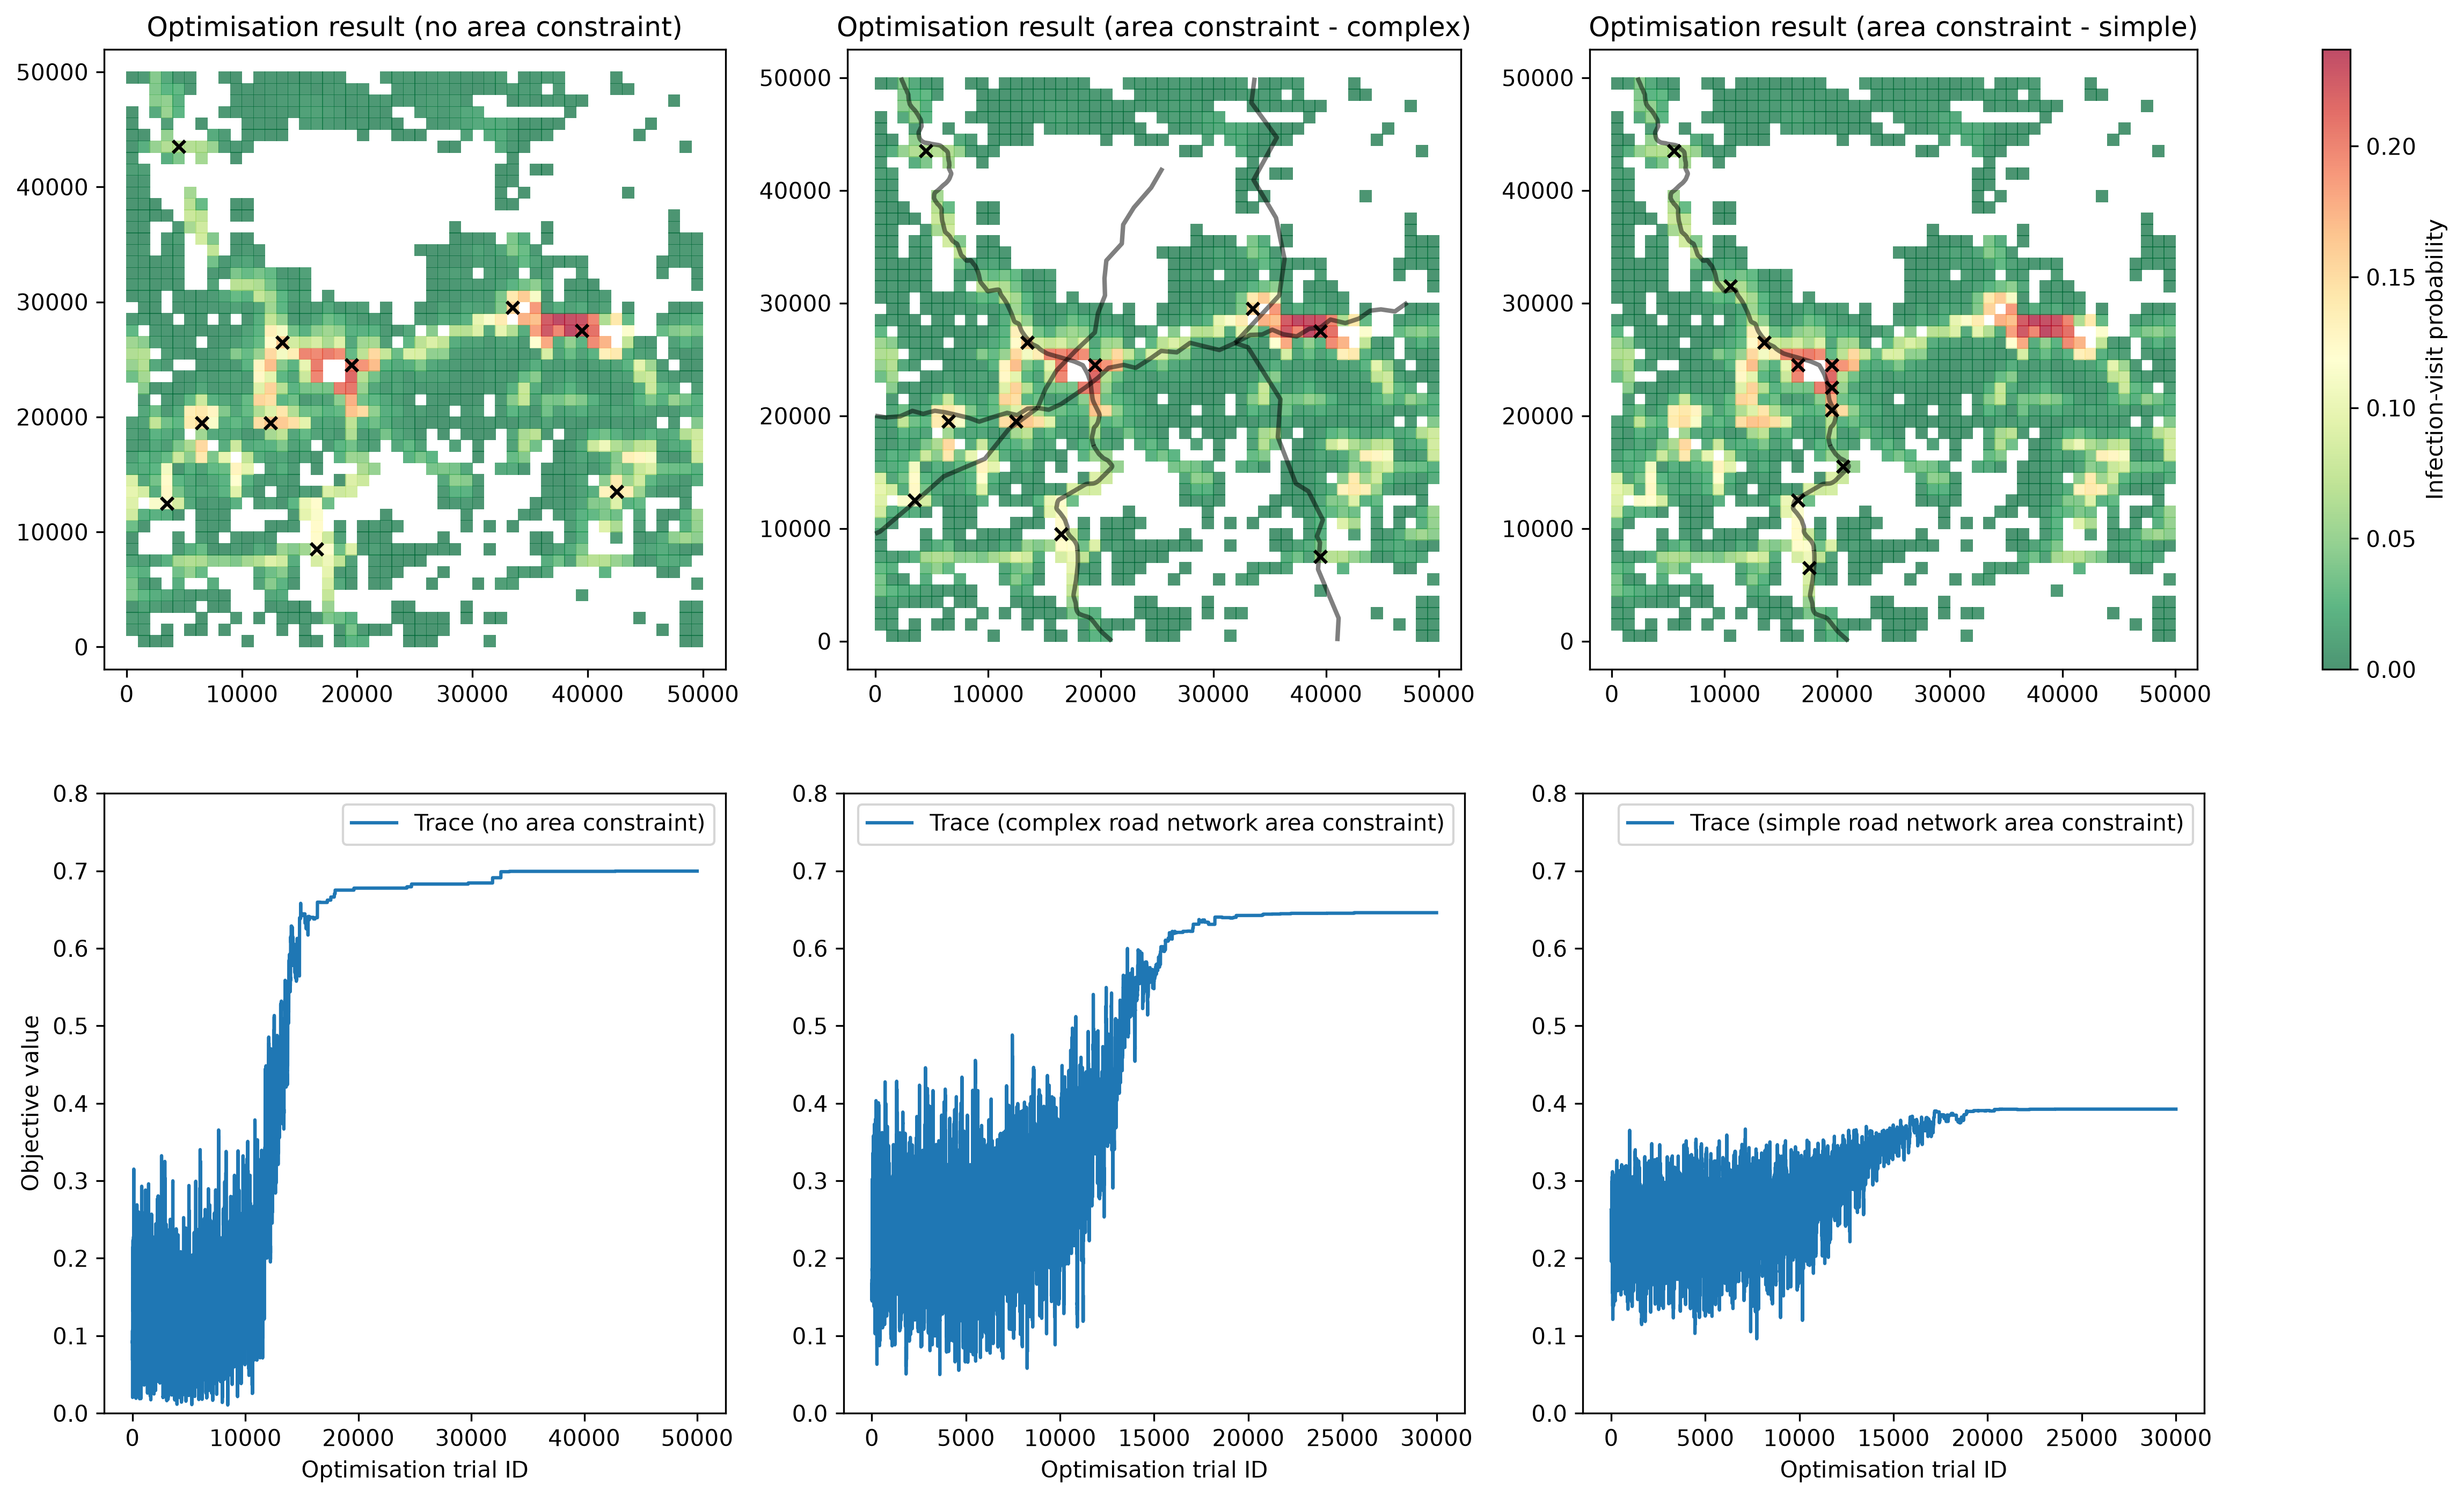

In [20]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 11), dpi=300)
gs  = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.045], wspace=0.25, hspace=0.2)

# axes
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
ax5 = fig.add_subplot(gs[1,2])
cax = fig.add_subplot(gs[0,3])   # dedicated colorbar axis (top-right column)

# --- plotting (example) ---
# IMPORTANT: fix vmin/vmax so the shared colorbar matches all three
vmin = (visit01[non0]/2000).min()
vmax = (visit01[non0]/2000).max()

im0 = ax0.scatter(host_positions_non0[:,0], host_positions_non0[:,1],
                  marker='s', s=30, linewidths=0, edgecolors='none', alpha=0.7,
                  c=visit01[non0]/2000, cmap='RdYlGn_r', vmin=vmin, vmax=vmax)
ax0.scatter(host_positions[config_01_nc_best,0], host_positions[config_01_nc_best,1],
            marker='x', s=30, c='black', label='optimal sites')
ax0.set_title('Optimisation result (no area constraint)')

im1 = ax1.scatter(host_positions_non0[:,0], host_positions_non0[:,1],
                  marker='s', s=30, linewidths=0, edgecolors='none', alpha=0.7,
                  c=visit01[non0]/2000, cmap='RdYlGn_r', vmin=vmin, vmax=vmax)
shp_road_complex.plot(ax=ax1, color='black', linewidth=2, alpha=0.5, label='road')
ax1.scatter(host_positions[config_01_ac_comp_best,0], host_positions[config_01_ac_comp_best,1],
            marker='x', s=30, c='black', label='optimal sites')
ax1.set_title('Optimisation result (area constraint - complex)')

im2 = ax2.scatter(host_positions_non0[:,0], host_positions_non0[:,1],
                  marker='s', s=30, linewidths=0, edgecolors='none', alpha=0.7,
                  c=visit01[non0]/2000, cmap='RdYlGn_r', vmin=vmin, vmax=vmax)
shp_road.plot(ax=ax2, color='black', linewidth=2, alpha=0.5, label='road')
ax2.scatter(host_positions[config_01_ac_best,0], host_positions[config_01_ac_best,1],
            marker='x', s=30, c='black', label='optimal sites')
ax2.set_title('Optimisation result (area constraint - simple)')

# traces (unchanged)
ax3.plot(np.arange(len(trace_01_nc)), trace_01_nc, label='Trace (no area constraint)')
ax4.plot(np.arange(len(trace_01_ac_comp)), trace_01_ac_comp, label='Trace (complex road network area constraint)')
ax5.plot(np.arange(len(trace_01_ac)), trace_01_ac, label='Trace (simple road network area constraint)')
for a in (ax3, ax4, ax5):
    a.set_xlabel('Optimisation trial ID'); a.set_ylim(0, 0.8); a.legend()
ax3.set_ylabel('Objective value')

# one colorbar for the three maps
cb = fig.colorbar(im0, cax=cax, label='Infection-visit probability')

plt.show()


# fig 5

In [6]:
def metric_kendal_dcor(w=10,s=52):
        # w,s = 10,52
        folder=f'8area_run0_nsite{w}_sfreq{s}'

        dir_metric = os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_metric')    ##sites=10
        print(dir_metric)

        filenames_road = [f for f in os.listdir(dir_metric)
                  if ('NoRoad' not in f) and f.endswith(".joblib")]
        # print(filenames_road)
        filenames_noroad = [f for f in os.listdir(dir_metric)
                    if ('NoRoad' in f) and f.endswith(".joblib")]

        # print(filenames_noroad)
        metric_list = [
            load(os.path.join(dir_metric, f)) for f in filenames_road
        ]

        metric_listNoRoad = [
            load(os.path.join(dir_metric, f)) for f in filenames_noroad
        ]
        # print(metric_listNoRoad)

        metric_list_flat = [flatten_dict(dic) for dic in metric_list]
        metric_df = pd.DataFrame(metric_list_flat)

        metric_list_flatNoRoad=[flatten_dict(dic) for dic in metric_listNoRoad]
        metric_dfNoRoad=pd.DataFrame(metric_list_flatNoRoad)[['area','objective']].rename(columns={'objective':'best_objective'})

        ### appending best objective
        metric_df = metric_df.merge(metric_dfNoRoad, on='area', how='left')
        metric_df['objective_prop'] = metric_df['objective']/metric_df['best_objective']
        metric_df=metric_df.sort_values(['area', 'road'], ascending=[True, True])

        ### CREATE MORE COLUMNS ===================================================================
        """Get the positions of the boundaries of the patch"""
        host_pos = distr_list[0]['xy']
        len(host_pos)
        # host_pos_50x50 = host_pos.reshape(50,50)
        # host_pos_50x50
        xmin, xmax = host_pos[:,0].min(), host_pos[:,0].max()
        ymin, ymax = host_pos[:,1].min(), host_pos[:,1].max()
        edge_left=host_pos[host_pos[:,0]==xmin]
        edge_right=host_pos[host_pos[:,0]==xmax]
        edge_lower=host_pos[host_pos[:,1]==ymin]
        edge_upper=host_pos[host_pos[:,1]==ymax]
        boundaries = np.vstack([edge_left, edge_right, edge_lower, edge_upper])

        metric_df['roadgroup']=metric_df['road'].str[:2]
        metric_df['sites_allowed_len']=metric_df['sites_allowed'].apply(len)
        metric_df['RCAP'] = metric_df['sites_allowed_len']/metric_df['num_host_pop_non0']
        metric_df['RCA'] = metric_df['road_coverage_area']
        metric_df['RCP'] = metric_df['road_coverage_plant']
        metric_df['RMS_All2AP'] = metric_df['RMS_toAllowed']
        metric_df['RMS_All2AP_wtd'] = metric_df['RMS_toAllowed_wtd']

        areas = metric_df['area'].tolist()
        roads = metric_df['road'].tolist()
        host_distr_ID = [int(a[-1])-1 for a in areas]

        def create_road_centrality_mean(host_distr, road_metric_df, area, road, wtd_plant=False):
            sites_allowed_ID = road_metric_df[(road_metric_df['area']==area)&(road_metric_df['road']==road) ]['sites_allowed'].item()
            host_pos_allowed = host_distr['xy'][sites_allowed_ID]
            cross_dist = cdist(host_pos_allowed, boundaries)
            shortest_dist = np.min(cross_dist, axis=1)  #shortest distance from each allowed cell to the boundaries
            if wtd_plant:
                host_pop = host_distr['host_population']
                weight_plant=host_pop[sites_allowed_ID]/np.sum(host_pop)
                road_centrality = np.mean((shortest_dist)*(weight_plant))  #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
            else:
                road_centrality = np.mean(shortest_dist)
            return road_centrality

        road_centrality_mean_list = [create_road_centrality_mean(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i], wtd_plant=False) for i in range(len(areas))]
        metric_df['MDB']= road_centrality_mean_list # mean distance to boundary

        road_centrality_mean_wtd_list = [create_road_centrality_mean(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i], wtd_plant=True) for i in range(len(areas))]
        metric_df['MDB_wtd']= road_centrality_mean_wtd_list


        def create_road_centrality(host_distr, road_metric_df, area, road, wtd_plant=False):
            sites_allowed_ID = road_metric_df[(road_metric_df['area']==area)&(road_metric_df['road']==road) ]['sites_allowed'].item()
            host_pos_allowed = host_distr['xy'][sites_allowed_ID]
            cross_dist = cdist(host_pos_allowed, boundaries)
            shortest_dist = np.min(cross_dist, axis=1)  #shortest distance from each allowed cell to the boundaries
            if wtd_plant:
                host_pop = host_distr['host_population']
                weight_plant=host_pop[sites_allowed_ID]/np.sum(host_pop)
                road_centrality = np.sum((shortest_dist)*(weight_plant))
            else:
                road_centrality = np.sum(shortest_dist)
            return road_centrality

        road_centrality_list = [create_road_centrality(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i], wtd_plant=False) for i in range(len(areas))]
        metric_df['TDB']= road_centrality_list  # total distance to boundary

        road_centrality_wtd_list = [create_road_centrality(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i], wtd_plant=True) for i in range(len(areas))]
        metric_df['TDB_wtd']= road_centrality_wtd_list


        def create_RMS_P2AP(host_distr, road_metric_df, area, road):
            host_pos = host_distr['xy']
            host_pos_non0 = host_distr['xy'][np.where(host_distr['host_population']>0)[0]]
            site_allowed_ID = road_metric_df[(road_metric_df['area']==area)&(road_metric_df['road']==road) ]['sites_allowed'].item()
            cross_dist = cdist(host_pos_non0, host_pos[site_allowed_ID])    # cross distance between each cell to all the allowed cells
            shortest_dist = np.min(cross_dist, axis=1)  #shortest distance from each cell to the allowed cells
            RMS_P2AP = (np.mean(shortest_dist**2))**0.5
            return RMS_P2AP

        RMS_P2AP_list = [create_RMS_P2AP(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i]) for i in range(len(areas))]
        metric_df['RMS_P2AP'] = RMS_P2AP_list

        def create_RMS_P2AP_wtd(host_distr, road_metric_df, area, road):
            host_pos = host_distr['xy']
            host_pos_non0 = host_distr['xy'][np.where(host_distr['host_population']>0)[0]]
            host_pop = host_distr['host_population']
            host_pop_non0 = host_distr['host_population'][np.where(host_distr['host_population']>0)[0]]
            host_pop_sum = np.sum(host_pop)
            weights_plant = host_pop_non0/host_pop_sum
            site_allowed_ID = road_metric_df[(road_metric_df['area']==area)&(road_metric_df['road']==road) ]['sites_allowed'].item()
            cross_dist = cdist(host_pos_non0, host_pos[site_allowed_ID])    # cross distance between each cell to all the allowed cells
            shortest_dist = np.min(cross_dist, axis=1)  #shortest distance from each cell to the allowed cells
            RMS_P2AP_wtd = (np.mean((shortest_dist**2)*weights_plant))**0.5
            return RMS_P2AP_wtd

        RMS_P2AP_wtd_list = [create_RMS_P2AP_wtd(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i]) for i in range(len(areas))]
        metric_df['RMS_P2AP_wtd'] = RMS_P2AP_wtd_list

        cols = ['road_length','RCA', 'RCAP','RCP',
                'MDB', 'MDB_wtd', 'TDB', 'TDB_wtd',
                'RMS_All2AP', 'RMS_All2AP_wtd',
                'RMS_P2AP', 'RMS_P2AP_wtd', 
                'objective','objective_prop']

        ### Kendall's tau correlation ===================================================
        metric_df_sub = metric_df[cols]
        corr_kendall = metric_df_sub.corr(method='kendall')
        corr_kendall=(corr_kendall['objective_prop'].drop(['objective', 'objective_prop']))
        corr_kendall.name=f"({w},{s})"
        corr_kendall_abs = pd.DataFrame(np.abs(corr_kendall))

        ### Distance correlation ===================================================
        corr_dist = {}
        for c in cols:
            c1, c2 = c, 'objective_prop'
            val = dcor.distance_correlation(metric_df[c1], metric_df[c2])
            # print(c, "\t",val)
            corr_dist[c1]=val
        corr_dist = pd.DataFrame.from_dict(corr_dist, orient='index', columns=[f"({w},{s})"]).drop(['objective', 'objective_prop'])

        return metric_df, corr_kendall_abs, corr_dist

In [7]:
w_list = [5,10,15]
s_list = [26,52,104]
metric_list = []
corr_kendall_list = []
corr_dist_list = []
for w in w_list:
    for s in s_list:
        metric, corr_kendall, corr_dist = metric_kendal_dcor(w=w,s=s)
        metric_list.append(metric)
        corr_kendall_list.append(corr_kendall)
        corr_dist_list.append(corr_dist)

/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana05_opt_3area2road/8area_run0_nsite5_sfreq26/output_metric
/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana05_opt_3area2road/8area_run0_nsite5_sfreq52/output_metric
/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana05_opt_3area2road/8area_run0_nsite5_sfreq104/output_metric
/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana05_opt_3area2road/8area_run0_nsite10_sfreq26/output_metric
/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis

In [8]:
corr_kendall_df = pd.concat(corr_kendall_list, axis=1, ignore_index=False).round(4)
corr_kendall_df.style.format('{:.4f}').highlight_max(axis=0) \
    .set_caption("<b><span style='font-size:20px'>Absolute Kendall's tau correlations</span></b>")

,"(5,26)","(5,52)","(5,104)","(10,26)","(10,52)","(10,104)","(15,26)","(15,52)","(15,104)"
road_length,0.6308,0.6225,0.6369,0.6851,0.6836,0.6964,0.6899,0.6943,0.7116
RCA,0.6064,0.5946,0.5675,0.6324,0.6231,0.6286,0.6430,0.6432,0.6434
RCAP,0.6859,0.6954,0.7175,0.7426,0.7549,0.7780,0.7434,0.7555,0.7778
RCP,0.7780,0.7878,0.7606,0.8309,0.8505,0.8314,0.8317,0.8474,0.8332
MDB,0.0819,0.0948,0.0984,0.0539,0.0483,0.0481,0.0710,0.0517,0.0475
MDB_wtd,0.2610,0.2741,0.2789,0.2568,0.2648,0.2484,0.2422,0.2401,0.2227
TDB,0.6030,0.6001,0.5769,0.6244,0.6171,0.6194,0.6343,0.6260,0.6229
TDB_wtd,0.7596,0.7681,0.7254,0.7744,0.7758,0.7535,0.7743,0.7692,0.7430
RMS_All2AP,0.6126,0.6057,0.6072,0.6593,0.6552,0.6580,0.6674,0.6688,0.6736
RMS_All2AP_wtd,0.6203,0.6169,0.6114,0.6955,0.6919,0.6969,0.7163,0.7130,0.7178


In [11]:
corr_dist_df = pd.concat(corr_dist_list, axis=1, ignore_index=False)
corr_dist_df.style.format('{:.4f}').highlight_max(axis=0)\
    .set_caption("<b><span style='font-size:20px'>Distance correlations</span></b>")

,"(5,26)","(5,52)","(5,104)","(10,26)","(10,52)","(10,104)","(15,26)","(15,52)","(15,104)"
road_length,0.7561,0.7444,0.7504,0.8231,0.8189,0.8286,0.8341,0.8346,0.8513
RCA,0.7546,0.7410,0.7102,0.7787,0.7747,0.7730,0.7894,0.7882,0.7893
RCAP,0.8346,0.8389,0.8465,0.8898,0.8993,0.9092,0.8908,0.8994,0.9150
RCP,0.8795,0.8852,0.8601,0.9084,0.9195,0.9128,0.9060,0.9185,0.9146
MDB,0.3125,0.3327,0.3518,0.2774,0.2770,0.2915,0.2690,0.2574,0.2618
MDB_wtd,0.3868,0.4097,0.4243,0.3830,0.3879,0.3809,0.3685,0.3650,0.3531
TDB,0.7561,0.7492,0.7249,0.7749,0.7678,0.7683,0.7837,0.7742,0.7751
TDB_wtd,0.8727,0.8793,0.8428,0.8896,0.8923,0.8735,0.8886,0.8900,0.8719
RMS_All2AP,0.7864,0.7739,0.7783,0.8336,0.8287,0.8342,0.8388,0.8369,0.8465
RMS_All2AP_wtd,0.7946,0.7943,0.7912,0.8626,0.8568,0.8592,0.8777,0.8711,0.8779


# fig 6

In [53]:
cwd = '/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code'
folder='8area_run0_nsite10_sfreq52'

dir_metric = os.path.join(cwd, 'Analysis/ana05_opt_3area2road/', folder, 'output_metric')    ##sites=10
dir_metric

'/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana05_opt_3area2road/8area_run0_nsite10_sfreq52/output_metric'

In [54]:
filenames_road=[f for f in os.listdir(dir_metric) if ('NoRoad' not in f) & (".joblib" in f)]
print(filenames_road)

filenames_noroad=[f for f in os.listdir(dir_metric) if 'NoRoad' in f]
print(filenames_noroad)

['metric_32.joblib', 'metric_015.joblib', 'metric_51.joblib', 'metric_20.joblib', 'metric_019.joblib', 'metric_43.joblib', 'metric_031.joblib', 'metric_16.joblib', 'metric_08.joblib', 'metric_75.joblib', 'metric_023.joblib', 'metric_79.joblib', 'metric_67.joblib', 'metric_040.joblib', 'metric_86.joblib', 'metric_2.joblib', 'metric_0.joblib', 'metric_84.joblib', 'metric_41.joblib', 'metric_22.joblib', 'metric_53.joblib', 'metric_30.joblib', 'metric_017.joblib', 'metric_18.joblib', 'metric_65.joblib', 'metric_042.joblib', 'metric_06.joblib', 'metric_021.joblib', 'metric_77.joblib', 'metric_033.joblib', 'metric_14.joblib', 'metric_69.joblib', 'metric_8.joblib', 'metric_4.joblib', 'metric_80.joblib', 'metric_73.joblib', 'metric_029.joblib', 'metric_037.joblib', 'metric_10.joblib', 'metric_61.joblib', 'metric_046.joblib', 'metric_02.joblib', 'metric_025.joblib', 'metric_57.joblib', 'metric_49.joblib', 'metric_34.joblib', 'metric_013.joblib', 'metric_45.joblib', 'metric_38.joblib', 'metric_2

In [55]:
"""
Load the metric files into lists. Each file contains a dictionary of metrics for one area.
"""
metric_list = [
    load(os.path.join(dir_metric, f)) for f in filenames_road
]

metric_listNoRoad = [
    load(os.path.join(dir_metric, f)) for f in filenames_noroad
]
print(len(metric_list), len(metric_listNoRoad))

133 8


In [56]:
metric_list_flat = [flatten_dict(dic) for dic in metric_list]
metric_df = pd.DataFrame(metric_list_flat)

metric_list_flatNoRoad=[flatten_dict(dic) for dic in metric_listNoRoad]
metric_dfNoRoad=pd.DataFrame(metric_list_flatNoRoad)[['area','objective']].rename(columns={'objective':'best_objective'})

### appending best objective
metric_df = metric_df.merge(metric_dfNoRoad, on='area', how='left')
metric_df['objective_prop'] = metric_df['objective']/metric_df['best_objective']

### add more metrics
metric_df['sites_allowed_len']=metric_df['sites_allowed'].apply(len)
metric_df['RCAP'] = metric_df['sites_allowed_len']/metric_df['num_host_pop_non0']


metric_df=metric_df.sort_values(['area', 'road'], ascending=[True, True])


display(metric_df)
# display(metric_dfNoRoad)

print(metric_df.columns)
# print(metric_dfNoRoad.columns)


,alpha,beta,sigma0,logistic_rate,prevalence,Pdetect,ntrees_survey,road,area,surveyfreq,...,RMS_toOpt,num_red_optimal,num_red_allowed,prop_red_allowedred,prop_red_allowed,objective,best_objective,objective_prop,sites_allowed_len,RCAP
16,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_0,01,52,...,17623.064433,8,21,0.380952,0.112676,0.318539,0.699604,0.455313,71,0.049443
32,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_1,01,52,...,16759.988067,8,23,0.347826,0.074766,0.392435,0.699604,0.560938,107,0.074513
7,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_2,01,52,...,11697.264638,8,40,0.200000,0.041237,0.598640,0.699604,0.855684,194,0.135097
58,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_3,01,52,...,9423.226624,9,47,0.191489,0.034221,0.630311,0.699604,0.900954,263,0.183148
0,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_4,01,52,...,9400.531900,9,52,0.173077,0.029605,0.645951,0.699604,0.923310,304,0.211699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,03_4,08,52,...,10068.386167,8,25,0.320000,0.029091,0.463999,0.670931,0.691575,275,0.139311
67,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,03_5,08,52,...,9729.131513,8,33,0.242424,0.017699,0.540627,0.670931,0.805786,452,0.228977
6,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,05_0,08,52,...,24595.040150,7,8,0.875000,0.129630,0.177513,0.670931,0.264578,54,0.027356
53,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,05_1,08,52,...,16151.668644,10,18,0.555556,0.097087,0.368394,0.670931,0.549079,103,0.052178


Index(['alpha', 'beta', 'sigma0', 'logistic_rate', 'prevalence', 'Pdetect',
       'ntrees_survey', 'road', 'area', 'surveyfreq', 'nsites', 'seed_opt',
       'num_host_pop_non0', 'sites_allowed', 'config_init', 'config_opt',
       'n_iter_actual', 'road_length', 'road_coverage_area',
       'road_coverage_plant', 'RMS_toRoad_wtd', 'RMS_toRoad',
       'RMS_toAllowed_wtd', 'RMS_toAllowed', 'RMS_toOpt_wtd', 'RMS_toOpt',
       'num_red_optimal', 'num_red_allowed', 'prop_red_allowedred',
       'prop_red_allowed', 'objective', 'best_objective', 'objective_prop',
       'sites_allowed_len', 'RCAP'],
      dtype='str')


In [57]:
"""
Load the metric files of Nigeria optimisations.
"""
dir_metric_nig = os.path.join(cwd, 'Analysis/ana11_opt_newPaper/output_metric')

### Has road constraint
filenames_road_nig = [f for f in os.listdir(dir_metric_nig) if ('NoRoad' not in f) & (".joblib" in f)]

metric_list_nig = [
    load(os.path.join(dir_metric_nig, f)) for f in filenames_road_nig
]

metric_list_nig_flat = [flatten_dict(dic) for dic in metric_list_nig]
metric_df_nig = pd.DataFrame(metric_list_nig_flat)

### No road constraint
filenames_noroad_nig = [f for f in os.listdir(dir_metric_nig) if ('NoRoad' in f) & (".joblib" in f)]
metric_list_noroad_nig = [
    load(os.path.join(dir_metric_nig, f)) for f in filenames_noroad_nig
]

metric_list_noroad_nig_flat = [flatten_dict(dic) for dic in metric_list_noroad_nig]
metric_df_noroad_nig=pd.DataFrame(metric_list_noroad_nig_flat)[['area','objective']].rename(columns={'objective':'best_objective'})

### Merge the two dataframes
metric_df_nig = metric_df_nig.merge(metric_df_noroad_nig, on='area', how='left')
metric_df_nig['objective_prop'] = np.minimum(metric_df_nig['objective']/metric_df_nig['best_objective'], 1)

### add more metrics
metric_df_nig['sites_allowed_len']=metric_df_nig['sites_allowed'].apply(len)
metric_df_nig['RCAP'] = metric_df_nig['sites_allowed_len']/metric_df_nig['num_host_pop_non0']


metric_df_nig=metric_df_nig.sort_values(['area', 'road'], ascending=[True, True])


Fitted parameters: L=1.2280, K=0.1279
[0.83288681 0.91614751 0.8421279  0.93889264 0.84746798]
[0.96877152 0.98825392 1.         0.98485943 1.        ]
mse=0.004356511110427428, R2=0.9146621958865071, mse_Nigeria=0.014793310684167612


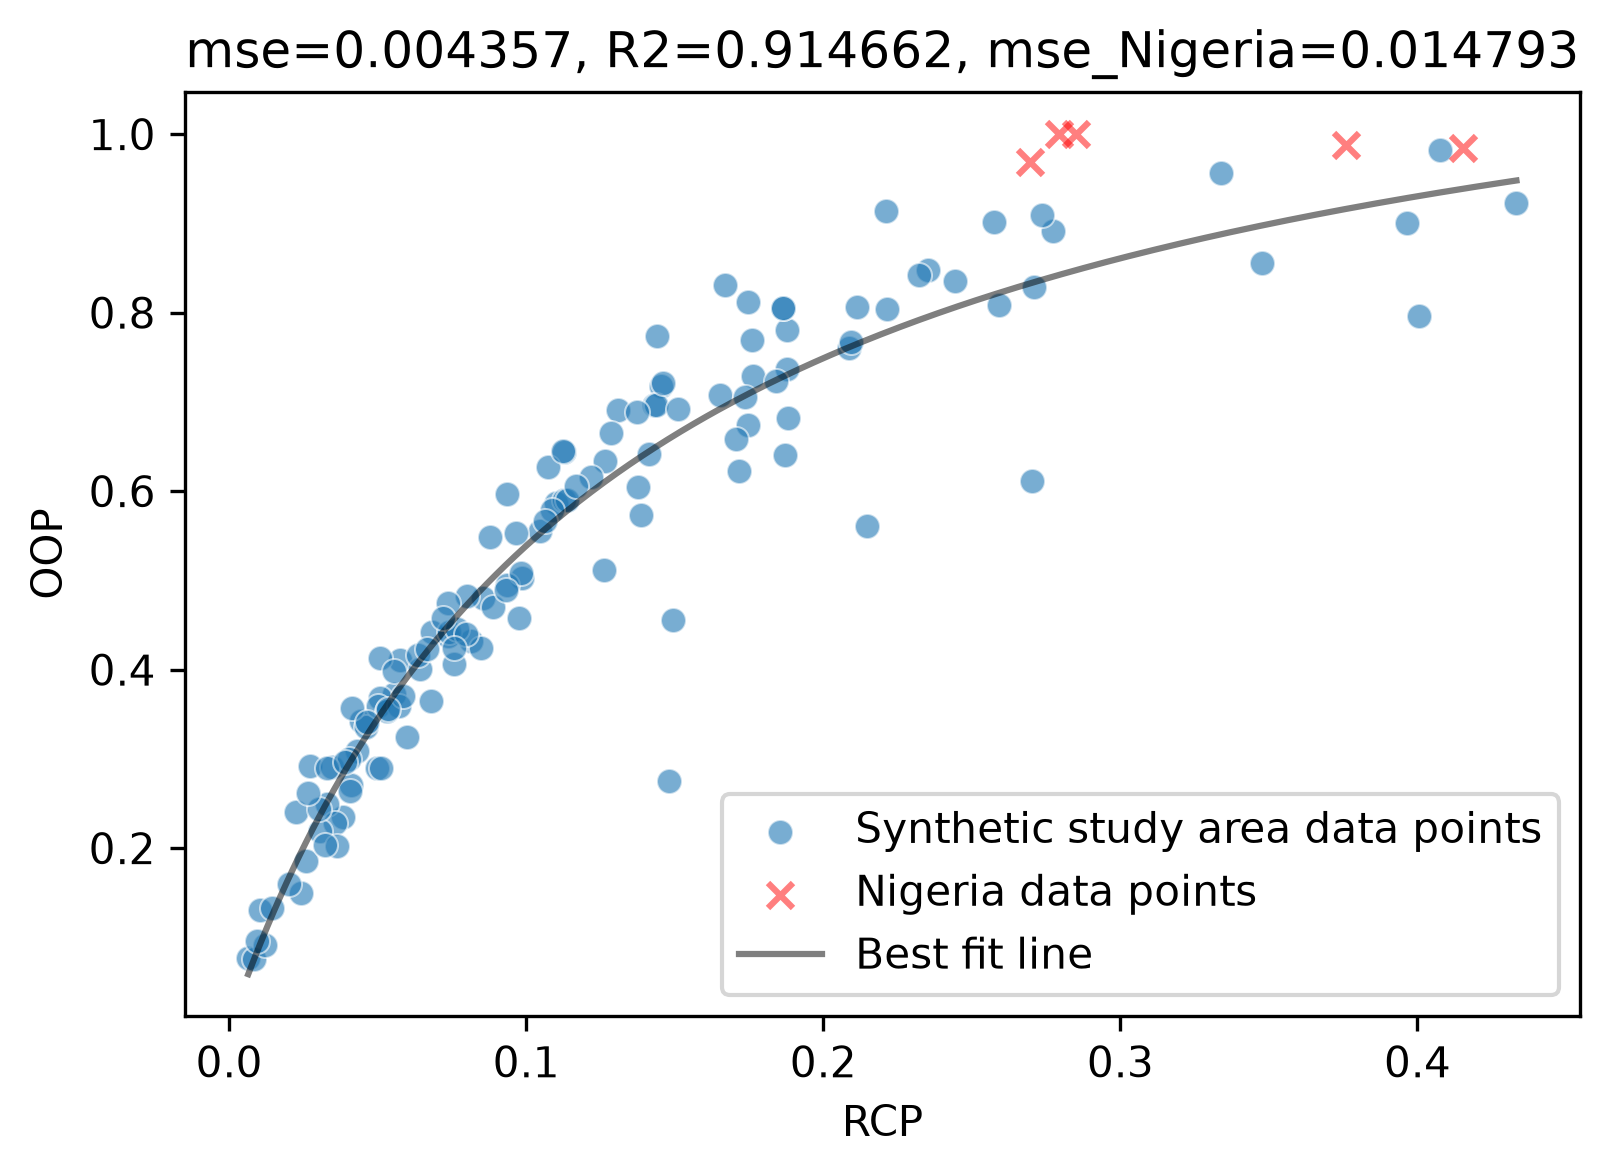

In [58]:
"""RCP - OOP relationship"""
# Assuming df has columns: road_coverage_plant and objective
x = metric_df["road_coverage_plant"].values
y = metric_df["objective_prop"].values


# guess a curve
from scipy.optimize import curve_fit

def mm(x, L, K):      # Michaelis–Menten
    return L * x / (K + x)

def expo(x, L, k):    # Exponential saturation
    return L * (1 - np.exp(-k*x))

p0 = (y.max(), np.median(x))  # simple starting guesses
pars, _ = curve_fit(mm, x, y, p0=p0, bounds=(0, np.inf))   # enforce positivity
L, K = pars
print(f'Fitted parameters: L={L:.4f}, K={K:.4f}')

x_fit = np.linspace(x.min(), x.max(), 400)
y_fit = mm(x_fit, L, K)


plt.figure(figsize=(6, 4), dpi=300)  # control size and resolution
sns.scatterplot(
        data=metric_df,
        # data=metric_dfRoad[(metric_dfRoad['area'].isin(['03', '05']))],
        # data=metric_dfRoad[(metric_dfRoad['area'].isin(['01', '05'])) & (metric_dfRoad['road'].isin(['01_0', '05_0']))],
        x='road_coverage_plant',
        y='objective_prop',
        # hue='area', #hue='road_centrality_mean_band',# hue='area',         # area is a column of strings
        # style='roadgroup',
        # markers={'01': 'o', '02':'D', '03': 's', '05': '^'},  # custom marker mapping
        # markers=True,
        # s=30,
        alpha=0.6,
        # palette='tab10'     # or 'Set2', 'husl', etc.
        label='Synthetic study area data points'
    )

### Add nigeria data points
x_nig = metric_df_nig["road_coverage_plant"].values
y_nig = metric_df_nig["objective_prop"].values
plt.scatter(x_nig, y_nig, color="red", alpha=0.5, marker="x", label="Nigeria data points")


plt.xlabel('RCP')
plt.ylabel('OOP')
# Plot fitted curve
# x_sorted = np.linspace(x.min(), x.max(), 400)
plt.plot(x_fit, y_fit, color="black", alpha=0.5, label="Best fit line")
# plt.plot(x_sorted, np.log(x_sorted)/np.log(200), color="black", alpha=0.5, label="Best fit line")

plt.legend(loc='lower right')
# plt.legend(title='Area', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# Metrics
y_pred = mm(x, L, K)
mse = np.mean((y - y_pred)**2)
r2  = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
print(mm(x_nig, L, K))
print(y_nig)
### Calculate MSE for Nigeria data points
mse_nig = np.mean((y_nig - mm(x_nig, L, K))**2)
print(f'mse={mse}, R2={r2}, mse_Nigeria={mse_nig}')
plt.title(f'mse={mse:4f}, R2={r2:4f}, mse_Nigeria={mse_nig:4f}')
plt.savefig(os.path.join(cwd, 'Plots for new paper/RCP_OOP_with_nigeria.png'), dpi=300)

plt.show()


Fitted parameters: L=1.4400, K=0.1496
mse=0.007663487988397471, R2=0.8498832620408938, mse_Nigeria=0.03868616564852769


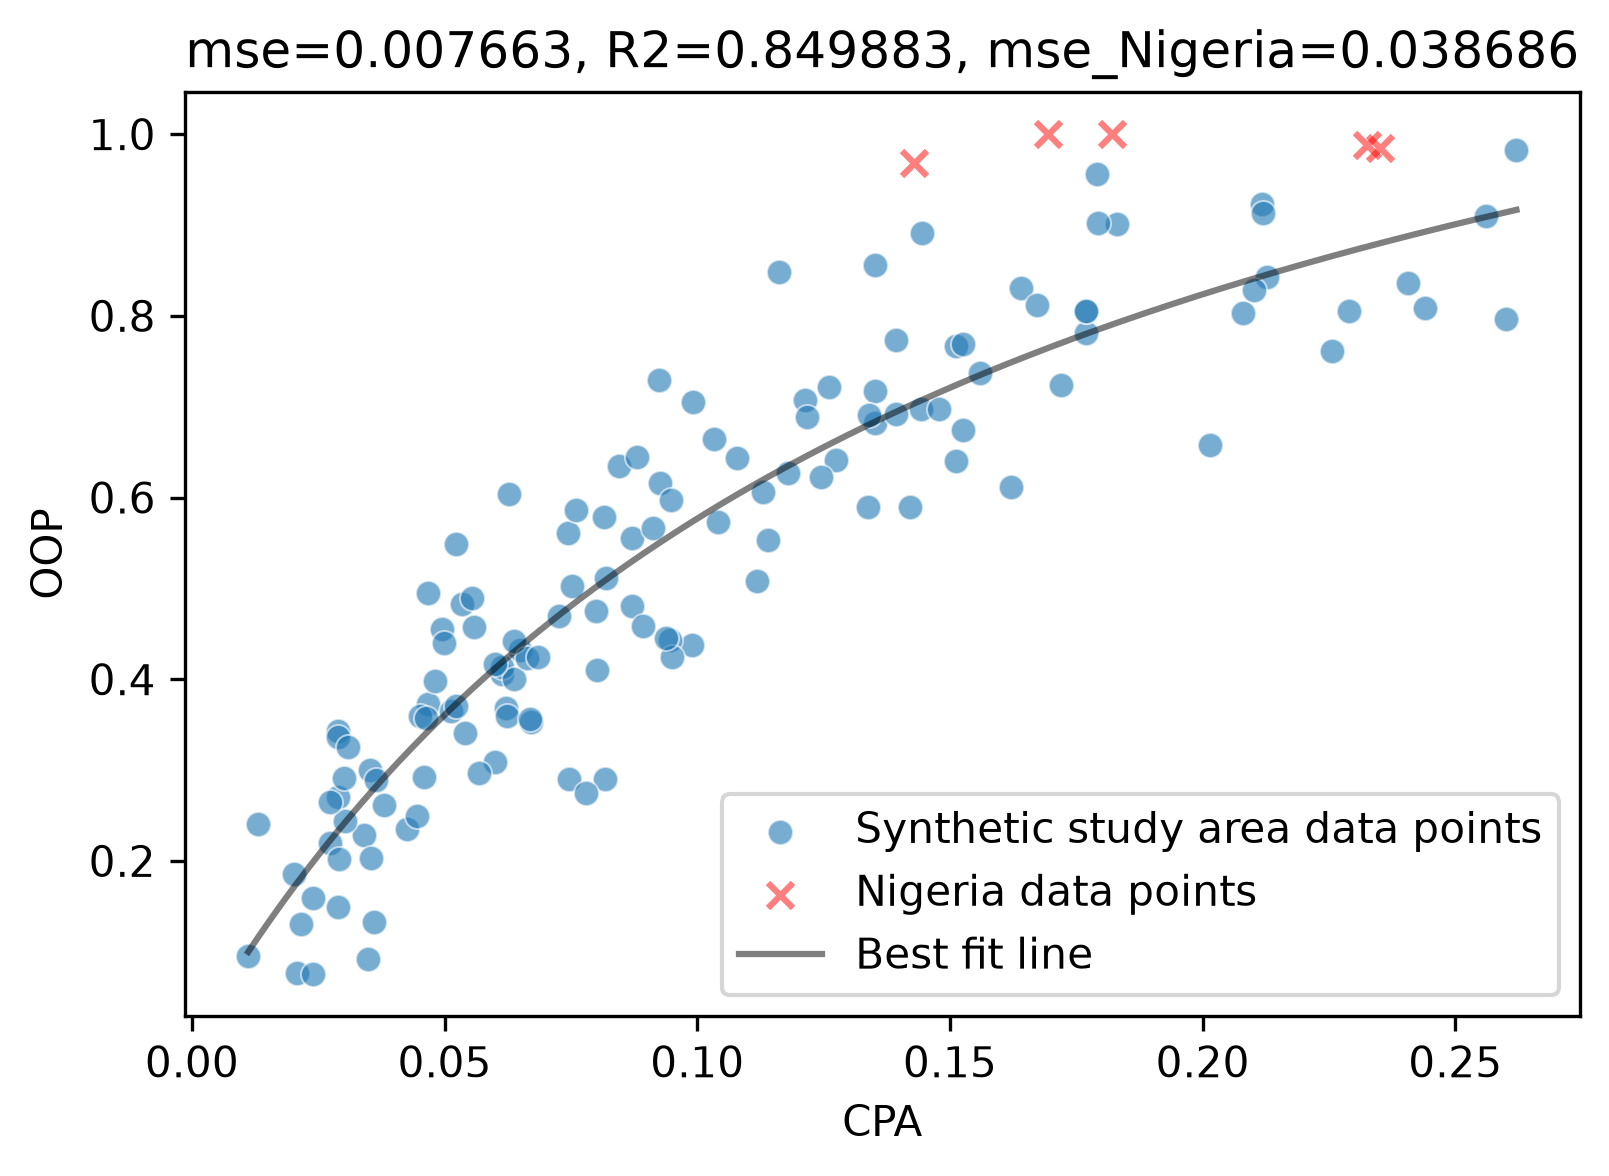

In [22]:
"""RCAP - OOP relationship"""
x = metric_df["RCAP"].values
y = metric_df["objective_prop"].values

p0 = (y.max(), np.median(x))  # simple starting guesses
pars, _ = curve_fit(mm, x, y, p0=p0, bounds=(0, np.inf))   # enforce positivity
L, K = pars
print(f'Fitted parameters: L={L:.4f}, K={K:.4f}')

x_fit = np.linspace(x.min(), x.max(), 400)
y_fit = mm(x_fit, L, K)

# Scatter plot
plt.figure(figsize=(6,4), dpi=300)
sns.scatterplot(
        data=metric_df,
        x='RCAP',
        y='objective_prop',
        # hue='area', #hue='road_centrality_mean_band',# hue='area',         # area is a column of strings
        # style='roadgroup',
        # markers={'01': 'o', '02':'D', '03': 's', '05': '^'},  # custom marker mapping
        # markers=True,
        # s=30,
        alpha=0.6,
        # palette='tab10'     # or 'Set2', 'husl', etc.
        label='Synthetic study area data points'
    )

### Add nigeria data points
x_nig = metric_df_nig["RCAP"].values
y_nig = metric_df_nig["objective_prop"].values
plt.scatter(x_nig, y_nig, color="red", alpha=0.5, marker="x", label="Nigeria data points")


plt.xlabel('CPA')
plt.ylabel('OOP')
# Plot fitted curve
plt.plot(x_fit, y_fit, color="black", alpha=0.5, label="Best fit line")
plt.legend(loc='lower right')
# plt.legend(title='Area', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# Metrics
y_pred = mm(x, L, K)
mse = np.mean((y - y_pred)**2)
r2  = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

### Calculate MSE for Nigeria data points
mse_nig = np.mean((y_nig - mm(x_nig, L, K))**2)
print(f'mse={mse}, R2={r2}, mse_Nigeria={mse_nig}')
plt.title(f'mse={mse:4f}, R2={r2:4f}, mse_Nigeria={mse_nig:4f}')
plt.savefig(os.path.join(cwd, 'Plots for new paper/RCAP_OOP_with_nigeria.png'), dpi=300)

plt.show()



Fitted parameters: L=1.2678, K=135038.0598
mse=0.013473067234615966, R2=0.7360819372815119


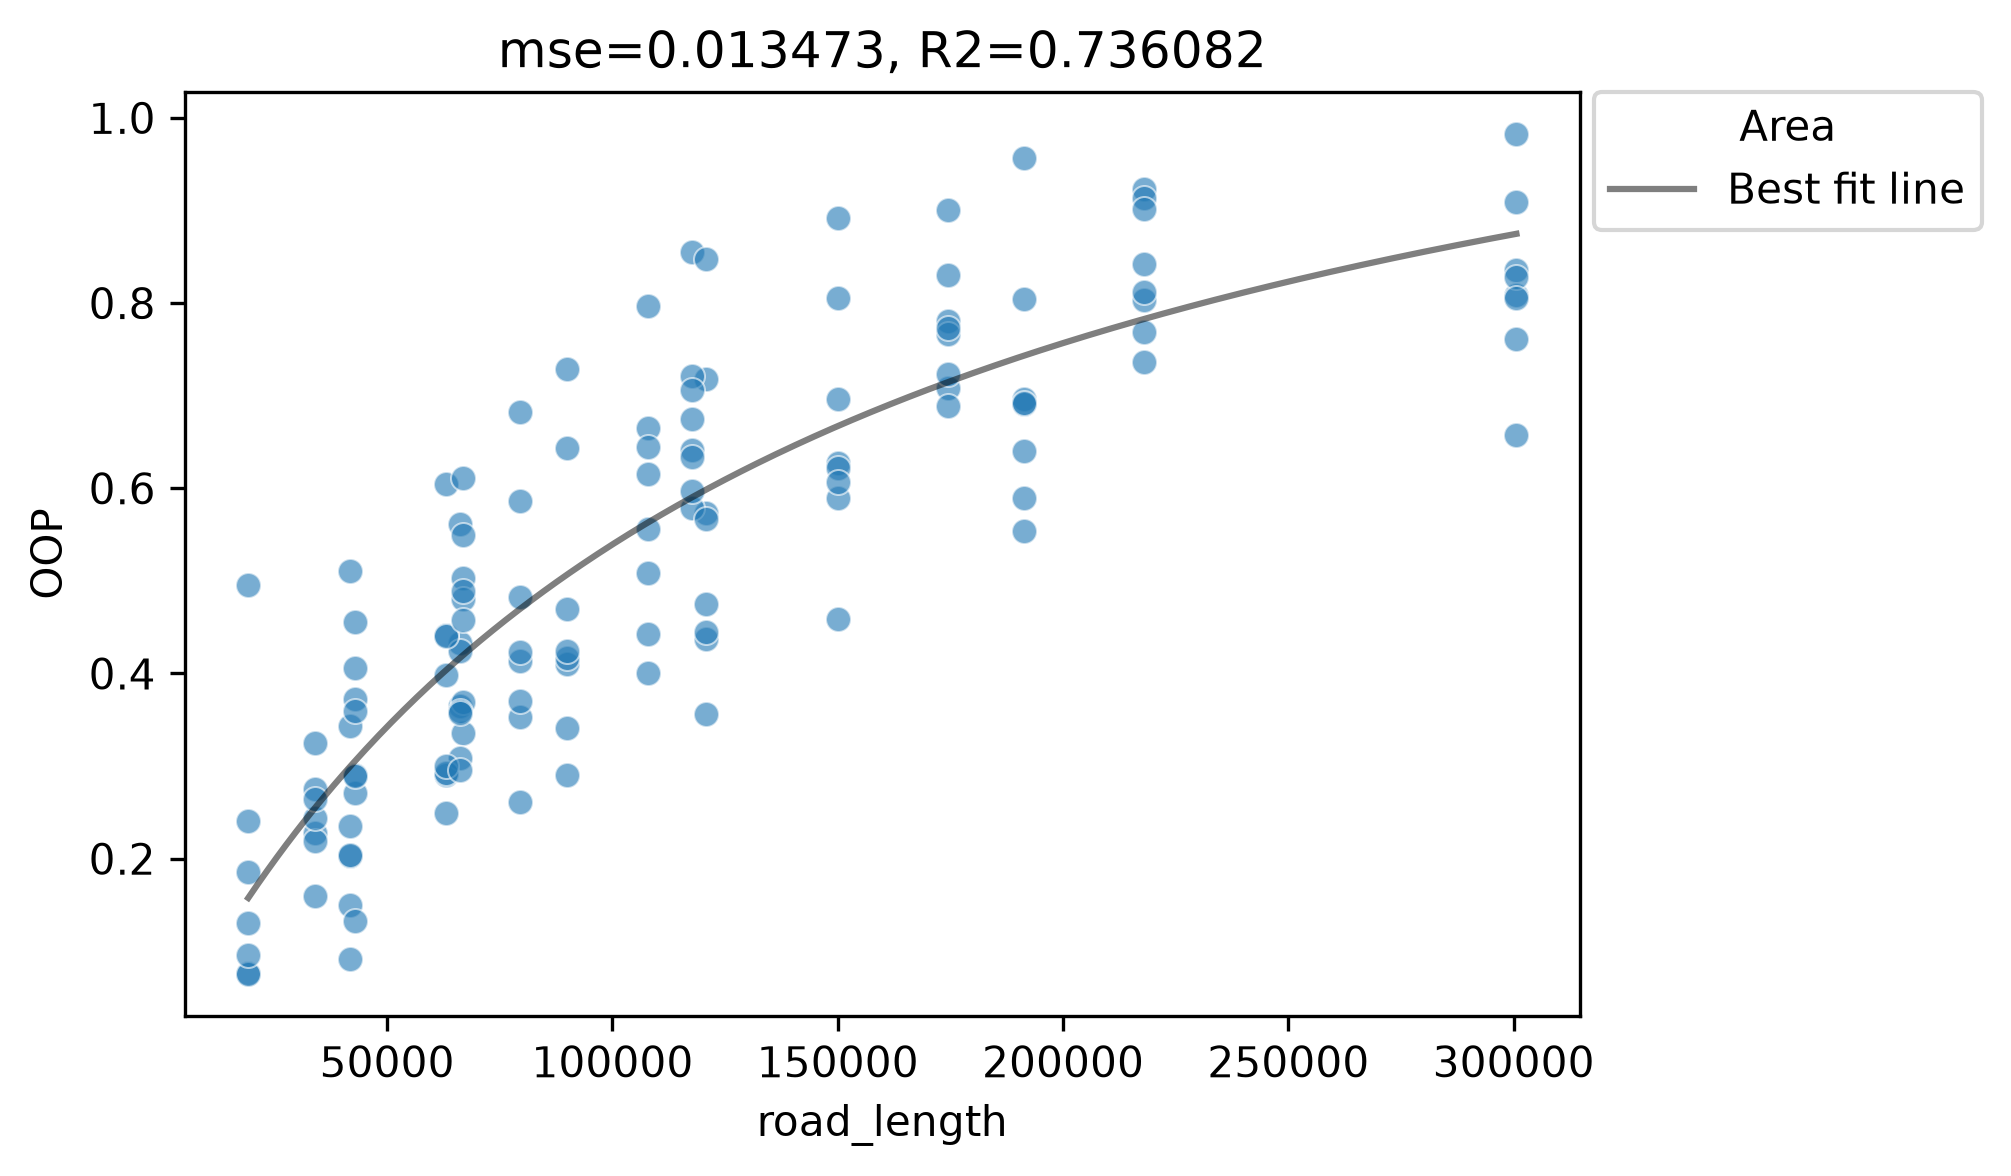

In [24]:
x = metric_df["road_length"].values
y = metric_df["objective_prop"].values

p0 = (y.max(), np.median(x))  # simple starting guesses
pars, _ = curve_fit(mm, x, y, p0=p0, bounds=(0, np.inf))   # enforce positivity
L, K = pars
print(f'Fitted parameters: L={L:.4f}, K={K:.4f}')

x_fit = np.linspace(x.min(), x.max(), 400)
y_fit = mm(x_fit, L, K)

# Scatter plot
plt.figure(figsize=(6,4), dpi=300)
sns.scatterplot(
        data=metric_df,
        x='road_length',
        y='objective_prop',
        # hue='area', #hue='road_centrality_mean_band',# hue='area',         # area is a column of strings
        # style='roadgroup',
        # markers={'01': 'o', '02':'D', '03': 's', '05': '^'},  # custom marker mapping
        # markers=True,
        # s=30,
        alpha=0.6,
        # palette='tab10'     # or 'Set2', 'husl', etc.
    )
plt.xlabel('road_length')
plt.ylabel('OOP')
# Plot fitted curve
plt.plot(x_fit, y_fit, color="black", alpha=0.5, label="Best fit line")
plt.legend(loc='lower right')
plt.legend(title='Area', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# Metrics
y_pred = mm(x, L, K)
mse = np.mean((y - y_pred)**2)
r2  = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

print(f'mse={mse}, R2={r2}')
plt.title(f'mse={mse:4f}, R2={r2:4f}')

plt.show()



In [25]:
metric_df_new = metric_kendal_dcor(w=10,s=52)[0]
metric_df_new

/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana05_opt_3area2road/8area_run0_nsite10_sfreq52/output_metric


,alpha,beta,sigma0,logistic_rate,prevalence,Pdetect,ntrees_survey,road,area,surveyfreq,...,RCA,RCP,RMS_All2AP,RMS_All2AP_wtd,MDB,MDB_wtd,TDB,TDB_wtd,RMS_P2AP,RMS_P2AP_wtd
16,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_0,01,52,...,0.0284,0.149280,17342.029870,301.937922,10521.126761,24.037554,747000.0,1706.666328,15742.376676,398.391850
32,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_1,01,52,...,0.0428,0.214735,16082.213778,278.919517,9728.971963,21.177188,1041000.0,2265.959161,14559.550178,368.020228
7,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_2,01,52,...,0.0776,0.347647,9896.261921,144.631956,11262.886598,20.210557,2185000.0,3920.848137,8663.992338,190.834567
58,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_3,01,52,...,0.1052,0.396398,5725.207420,86.272166,11193.916350,17.394554,2944000.0,4574.767631,5113.135087,113.831770
0,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,01_4,01,52,...,0.1216,0.433303,5188.063222,68.733622,11003.289474,16.062692,3345000.0,4883.058469,4462.861293,90.690545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,03_4,08,52,...,0.1100,0.151064,5912.258452,130.442357,11287.272727,6.957190,3104000.0,1913.227187,6045.420785,146.796286
67,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,03_5,08,52,...,0.1808,0.211347,3928.460258,84.088442,9707.964602,5.228325,4388000.0,2363.203004,3808.485167,94.630849
6,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,05_0,08,52,...,0.0216,0.040697,23796.798104,441.919160,5055.555556,3.122128,273000.0,168.594901,23815.431385,497.323821
53,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,05_1,08,52,...,0.0412,0.087888,14178.674127,254.006164,9631.067961,8.364794,992000.0,861.573824,14352.382431,285.851639


Fitted parameters: L=1.0733, K=1037690.5129


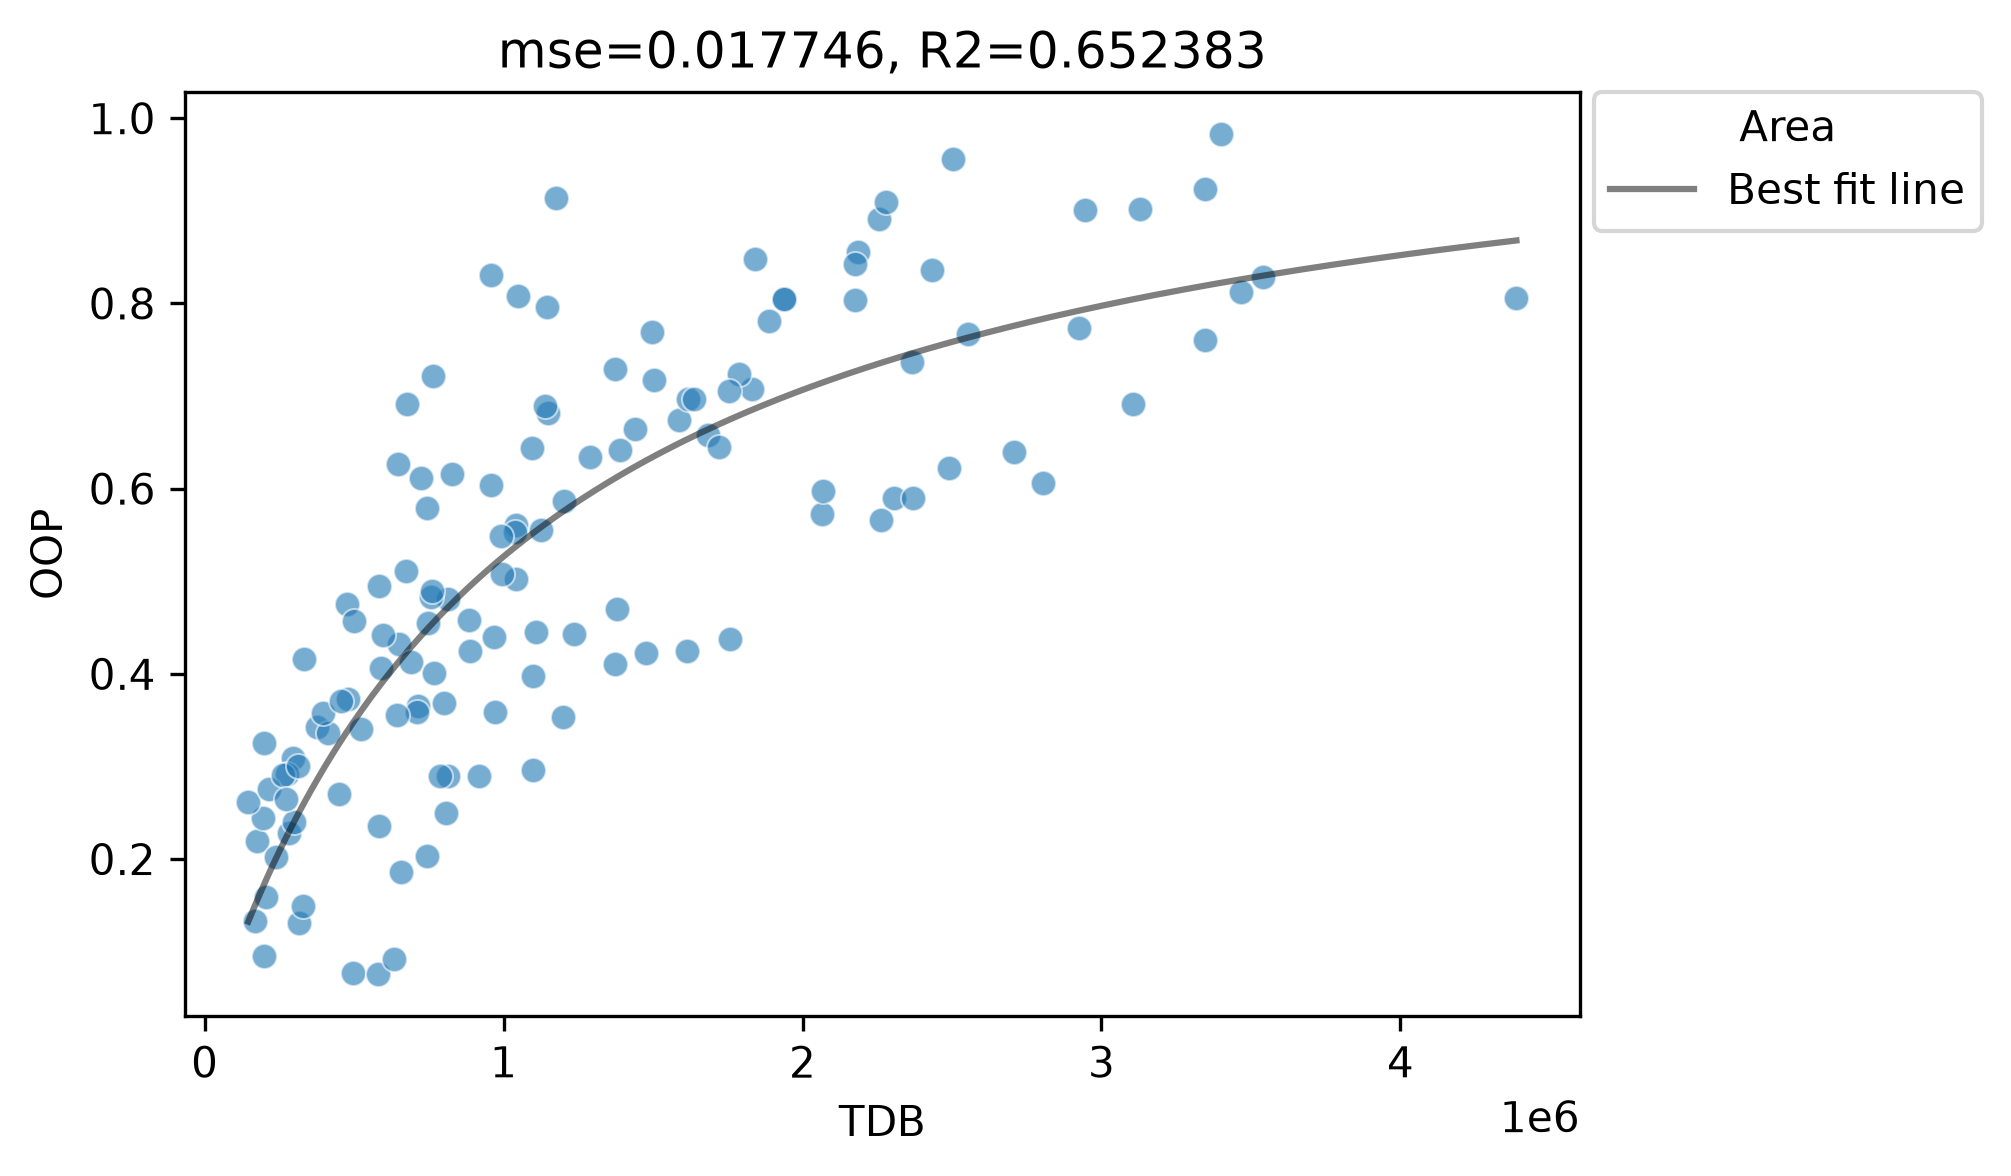

In [26]:
x = metric_df_new["TDB"].values
y = metric_df_new["objective_prop"].values


p0 = (y.max(), np.median(x))  # simple starting guesses
pars, _ = curve_fit(mm, x, y, p0=p0, bounds=(0, np.inf))   # enforce positivity
L, K = pars
print(f'Fitted parameters: L={L:.4f}, K={K:.4f}')

x_fit = np.linspace(x.min(), x.max(), 400)
y_fit = mm(x_fit, L, K)

# Scatter plot
plt.figure(figsize=(6,4), dpi=300)
sns.scatterplot(
        data=metric_df_new,
        x='TDB',
        y='objective_prop',
        # hue='area', #hue='road_centrality_mean_band',# hue='area',         # area is a column of strings
        # style='roadgroup',
        # markers={'01': 'o', '02':'D', '03': 's', '05': '^'},  # custom marker mapping
        # markers=True,
        # s=30,
        alpha=0.6,
        # palette='tab10'     # or 'Set2', 'husl', etc.
    )
plt.xlabel('TDB')
plt.ylabel('OOP')
# Plot fitted curve
plt.plot(x_fit, y_fit, color="black", alpha=0.5, label="Best fit line")

# coeffs = np.polyfit(x, y, deg=3)
# poly_fn = np.poly1d(coeffs)
# x_sorted = np.linspace(min(x), max(x), 200)
# plt.plot(x_sorted, poly_fn(x_sorted), color="black", alpha=0.5, label="Best fit line")

plt.legend(loc='lower right')
plt.legend(title='Area', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)


# Metrics
y_pred = mm(x, L, K)
mse = np.mean((y - y_pred)**2)
r2  = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

plt.title(f'mse={mse:4f}, R2={r2:4f}')

plt.show()


# fig S7

In [2]:
# Read area distributions
dir_studyarea = '/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana10_opt_testRoadBeingAwayFromHotspot'

distr_list = [
    load(os.path.join(dir_studyarea,f'host_distributions/area{i}.joblib')) for i in range(3)
]

In [3]:
# load simulations files
df_sims_list=[
    load(os.path.join(dir_studyarea, f'df_sims{i}.joblib')) for i in range(3)
]
for i in range(3):
    print(len(df_sims_list[i]))

2000
2000
2000


In [ ]:
x = df_sims_list[0][0]['x']
y = df_sims_list[0][0]['y']

# Calculate visit probabilities for each area
visit_prob_list = []
for sims in df_sims_list:
    visit_prob_area = get_visit_prob(sims)
    visit_prob_list.append(visit_prob_area)

In [17]:
# read road shapefiles
roads_shp=[gpd.read_file(os.path.join(dir_studyarea, 'road_patterns', f'roadnetwork{i}.shp')) for i in range(4)]

In [ ]:
# Read optimisation result metrics
dir_metric = os.path.join(dir_studyarea, 'output_metric')    ##sites=10
filenames_road=[f for f in os.listdir(dir_metric) if ('NoRoad' not in f) & (".joblib" in f)]
filenames_noroad=[f for f in os.listdir(dir_metric) if 'NoRoad' in f]

print(filenames_road)
print(filenames_noroad)

metric_list = [
    load(os.path.join(dir_metric, f)) for f in filenames_road
]

metric_listNoRoad = [
    load(os.path.join(dir_metric, f)) for f in filenames_noroad
]
print(len(metric_list), len(metric_listNoRoad))

/Users/biqingwang/Library/CloudStorage/GoogleDrive-biqingwang3@gmail.com/My Drive/00 Postgraduate Warwick/ES98C-Research/03 Work/99 Main code/Analysis/ana10_opt_testRoadBeingAwayFromHotspot/output_metric
['metric_road0_area0_surveyfreq52_nsites10.joblib', 'metric_road3_area2_surveyfreq52_nsites10.joblib', 'metric_road1_area0_surveyfreq52_nsites10.joblib', 'metric_road2_area2_surveyfreq52_nsites10.joblib', 'metric_road1_area1_surveyfreq52_nsites10.joblib']
['metric_NoRoad_area2_surveyfreq52_nsites10.joblib', 'metric_NoRoad_area1_surveyfreq52_nsites10.joblib', 'metric_NoRoad_area0_surveyfreq52_nsites10.joblib']
5 3


In [24]:
metric_list_flat = [flatten_dict(dic) for dic in metric_list]
metric_df = pd.DataFrame(metric_list_flat)

metric_list_flatNoRoad=[flatten_dict(dic) for dic in metric_listNoRoad]
metric_dfNoRoad=pd.DataFrame(metric_list_flatNoRoad)[['area','objective']].rename(columns={'objective':'best_objective'})

### appending best objective
metric_df = metric_df.merge(metric_dfNoRoad, on='area', how='left')
metric_df=metric_df.sort_values(['area', 'road'], ascending=[True, True])

"""create more metrics"""
metric_df['sites_allowed_len']=metric_df['sites_allowed'].apply(len)
metric_df['road_coverage_areaNon0'] = metric_df['sites_allowed_len']/metric_df['num_host_pop_non0']
# metric_df['roadgroup']=metric_df['road'].str[:2]
metric_df['objective_prop'] = metric_df['objective']/metric_df['best_objective']


areas = metric_df['area'].tolist()
roads = metric_df['road'].tolist()
host_distr_ID = [a for a in areas]


"""Get the positions of the boundaries of the patch"""
host_pos = distr_list[0]['xy']
len(host_pos)
# host_pos_50x50 = host_pos.reshape(50,50)
# host_pos_50x50
xmin, xmax = host_pos[:,0].min(), host_pos[:,0].max()
ymin, ymax = host_pos[:,1].min(), host_pos[:,1].max()
edge_left=host_pos[host_pos[:,0]==xmin]
edge_right=host_pos[host_pos[:,0]==xmax]
edge_lower=host_pos[host_pos[:,1]==ymin]
edge_upper=host_pos[host_pos[:,1]==ymax]
boundaries = np.vstack([edge_left, edge_right, edge_lower, edge_upper])
len(boundaries)
# plt.scatter(boundaries[:,0], boundaries[:,1])

###################### road_centrality(_wtd)= sum(shortest distance from allowed cells to patch boundaries) (wtd by %plant) #########################
def create_road_centrality_mean(host_distr, road_metric_df, area, road, wtd_plant=False):
    sites_allowed_ID = road_metric_df[(road_metric_df['area']==area)&(road_metric_df['road']==road) ]['sites_allowed'].item()
    host_pos_allowed = host_distr['xy'][sites_allowed_ID]
    cross_dist = cdist(host_pos_allowed, boundaries)
    shortest_dist = np.min(cross_dist, axis=1)  #shortest distance from each allowed cell to the boundaries
    if wtd_plant:
        host_pop = host_distr['host_population']
        weight_plant=host_pop[sites_allowed_ID]/np.sum(host_pop)
        # road_centrality = np.sum((shortest_dist**2)*(weight_plant**0.5))
        road_centrality = np.mean((shortest_dist)*(weight_plant**0.1))  #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    else:
        # road_centrality = np.sum(shortest_dist)
        road_centrality = np.mean(shortest_dist)
    return road_centrality

road_centrality_mean_list = [create_road_centrality_mean(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i], wtd_plant=False) for i in range(len(areas))]
metric_df['road_centrality_mean']= road_centrality_mean_list


###################### road_centrality(_wtd)= sum(shortest distance from allowed cells to patch boundaries) (wtd by %plant) #########################
def create_road_centrality(host_distr, road_metric_df, area, road, wtd_plant=False):
    sites_allowed_ID = road_metric_df[(road_metric_df['area']==area)&(road_metric_df['road']==road) ]['sites_allowed'].item()
    host_pos_allowed = host_distr['xy'][sites_allowed_ID]
    cross_dist = cdist(host_pos_allowed, boundaries)
    shortest_dist = np.min(cross_dist, axis=1)  #shortest distance from each allowed cell to the boundaries
    if wtd_plant:
        host_pop = host_distr['host_population']
        weight_plant=host_pop[sites_allowed_ID]/np.sum(host_pop)
        # road_centrality = np.sum((shortest_dist**2)*(weight_plant**0.5))
        road_centrality = np.sum((shortest_dist)*(weight_plant))
    else:
        # road_centrality = np.sum(shortest_dist)
        road_centrality = np.sum(shortest_dist)
    return road_centrality

road_centrality_list = [create_road_centrality(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i], wtd_plant=False) for i in range(len(areas))]
metric_df['road_centrality']= road_centrality_list

road_centrality_wtd_list = [create_road_centrality(distr_list[host_distr_ID[i]], metric_df, areas[i], roads[i], wtd_plant=True) for i in range(len(areas))]
metric_df['road_centrality_wtd']= road_centrality_wtd_list

display(metric_df)
# display(metric_dfNoRoad)

print(metric_df.columns)

,alpha,beta,sigma0,logistic_rate,prevalence,Pdetect,ntrees_survey,road,area,surveyfreq,...,prop_red_allowedred,prop_red_allowed,objective,best_objective,sites_allowed_len,road_coverage_areaNon0,objective_prop,road_centrality_mean,road_centrality,road_centrality_wtd
0,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,0,0,52,...,0.409091,0.088235,0.383254,0.693861,102,0.071429,0.552349,8352.941176,852000.0,1833.844693
2,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,1,0,52,...,1.000000,0.017241,0.109248,0.693861,58,0.040616,0.157450,14620.689655,848000.0,319.195235
4,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,1,1,52,...,0.304348,0.065421,0.399372,0.670667,107,0.073793,0.595485,12813.084112,1371000.0,2783.834215
3,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,2,2,52,...,0.391304,0.084112,0.396627,0.677869,107,0.073187,0.585109,12607.476636,1349000.0,2727.930625
1,3.5,2980.957987,0.01,0.1693,0.05,0.75,30,3,2,52,...,0.380952,0.067797,0.464076,0.677869,118,0.080711,0.684610,11983.050847,1414000.0,1415.819159


Index(['alpha', 'beta', 'sigma0', 'logistic_rate', 'prevalence', 'Pdetect',
       'ntrees_survey', 'road', 'area', 'surveyfreq', 'nsites', 'seed_opt',
       'num_host_pop_non0', 'sites_allowed', 'config_init', 'config_opt',
       'n_iter_actual', 'road_length', 'road_coverage_area',
       'road_coverage_plant', 'RMS_toRoad_wtd', 'RMS_toRoad',
       'RMS_toAllowed_wtd', 'RMS_toAllowed', 'RMS_toOpt_wtd', 'RMS_toOpt',
       'num_red_optimal', 'num_red_allowed', 'prop_red_allowedred',
       'prop_red_allowed', 'objective', 'best_objective', 'sites_allowed_len',
       'road_coverage_areaNon0', 'objective_prop', 'road_centrality_mean',
       'road_centrality', 'road_centrality_wtd'],
      dtype='str')


In [ ]:
# take L, K values from the RCP-OOP relationship fitted curve. 
# Change manually if L, K values change.
L=1.2280
K=0.1279
x_fit = np.linspace(0, 0.4, 400) # adjust the range of x values if needed.
def mm(x, L, K):      # Michaelis–Menten
    return L * x / (K + x)
y_fit = mm(x_fit, L, K)

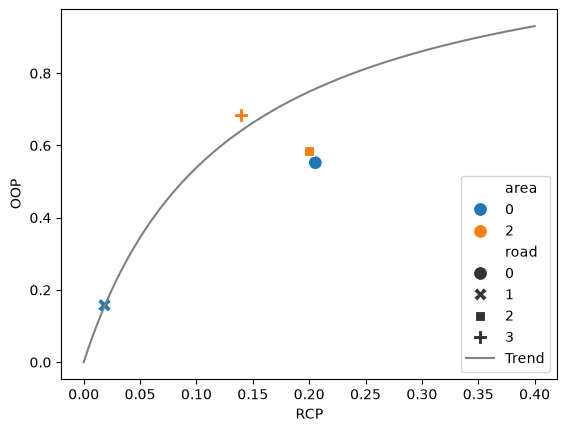

In [23]:
select = np.isin(metric_df['area'], [0,2])
sns.scatterplot(data=metric_df[select], 
                x="road_coverage_plant", 
                y="objective_prop",
                hue='area',
                style='road',
                palette='tab10',
                # marker='X',
                markers=True,
                s=100
                )


# Plot fitted curve
x_sorted = np.linspace(0, 0.4, 200)
# plt.plot(x_sorted, poly_fn(x_sorted), color="grey", label="Trend")
plt.plot(x_fit, y_fit, color="grey", label="Trend")

plt.xlabel('RCP')
plt.ylabel('OOP')
plt.legend(loc='lower right')
plt.show()

In [15]:
area_road_perm = np.array(metric_df[select][['area','road']])
area_road_perm

array([[0, 0],
       [0, 1],
       [2, 2],
       [2, 3]])

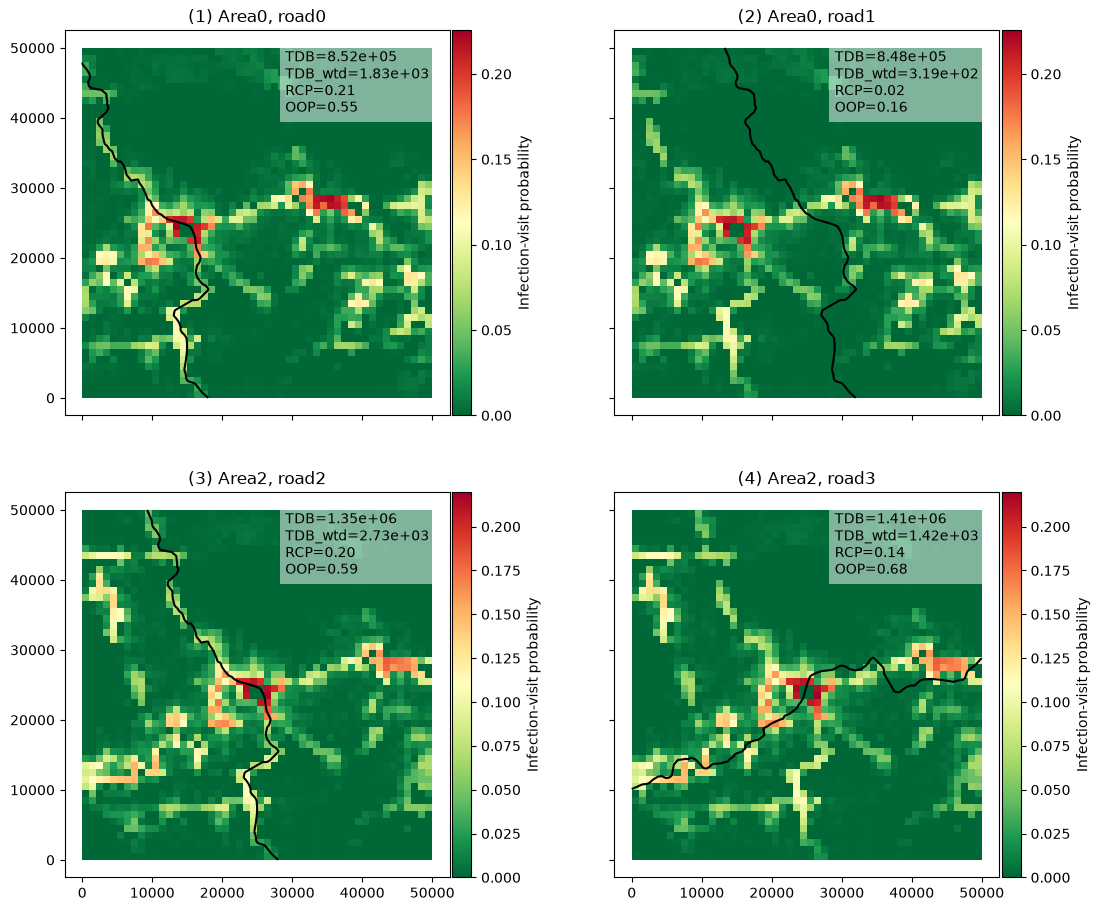

In [21]:
fig, axes = plt.subplots(2,2, figsize = (13,11), sharex=True, sharey=True)
ax = axes.ravel()

for i, perm in enumerate(area_road_perm):
    areaID = perm[0]
    roadID = perm[1]
    select = (metric_df['area']==areaID) & (metric_df['road']==roadID)
    RCP= metric_df[select]['road_coverage_plant'].item()
    OOP= metric_df[select]['objective_prop'].item()
    MDB = metric_df[select]['road_centrality_mean'].item()   # mean distance to boundary
    TDB = metric_df[select]['road_centrality'].item()
    TDB_wtd = metric_df[select]['road_centrality_wtd'].item()
    fig0=ax[i].scatter(x ,y, marker='s', s=25,
                linewidths=0, edgecolors='none', alpha=1, 
                c=visit_prob_list[areaID], cmap='RdYlGn_r')
    fig.colorbar(fig0, ax=ax[i], label='Infection-visit probability', pad=0.005, shrink=1)
    roads_shp[roadID].plot(color='black', ax=ax[i])
    # ax[i].legend(loc='upper right')
    ax[i].set_title(f'({i+1}) Area{areaID}, road{roadID}')
    # ax[i].set_subtitle(f'(Mean distance to boundary={MDTB},RCP={RCP:.4f},OOP={OOP:.4f})')
    # ax[i].text(0.5, 1.02, "Subtitle", transform=ax[i].transAxes,
        # ha="center", va="bottom", fontsize=10, color="gray")
    ax[i].text(
    29000, 45000,             # x, y in data coordinates
    # f"MDB={MDB:.2e}\nRCP={RCP:.2f}\nOOP={OOP:.2f}",         # text
    f"TDB={TDB:.2e}\nTDB_wtd={TDB_wtd:.2e}\nRCP={RCP:.2f}\nOOP={OOP:.2f}",         # text
    color="black",            # text color
    fontsize=10,
    ha="left",              # horizontal alignment
    va="center",              # vertical alignment
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none")  # background box
    )
# plt.tight_layout()
plt.show()

# fig S8

In [27]:
path_trace = os.path.join(cwd, 'Analysis/ana11_opt_newPaper/output_trace')
filenames_trace = sorted([f for f in os.listdir(path_trace) if f.startswith('trace_')])
print(filenames_trace)

trace_dict = {}
for f in filenames_trace:
    # key = f.replace('.joblib', '')
    trace_dict[f] = load(os.path.join(path_trace, f))

len(trace_dict)

['trace_objval_NoRoad_area_nigeria_anambra_surveyfreq52_nsites10.joblib', 'trace_objval_NoRoad_area_nigeria_kebbi_surveyfreq52_nsites10.joblib', 'trace_objval_NoRoad_area_nigeria_nasarawa_surveyfreq52_nsites10.joblib', 'trace_objval_NoRoad_area_nigeria_ogun_surveyfreq52_nsites10.joblib', 'trace_objval_NoRoad_area_nigeria_plateau_surveyfreq52_nsites10.joblib', 'trace_objval_area_nigeria_anambra_surveyfreq52_nsites10.joblib', 'trace_objval_area_nigeria_kebbi_surveyfreq52_nsites10.joblib', 'trace_objval_area_nigeria_nasarawa_surveyfreq52_nsites10.joblib', 'trace_objval_area_nigeria_ogun_surveyfreq52_nsites10.joblib', 'trace_objval_area_nigeria_plateau_surveyfreq52_nsites10.joblib']


10

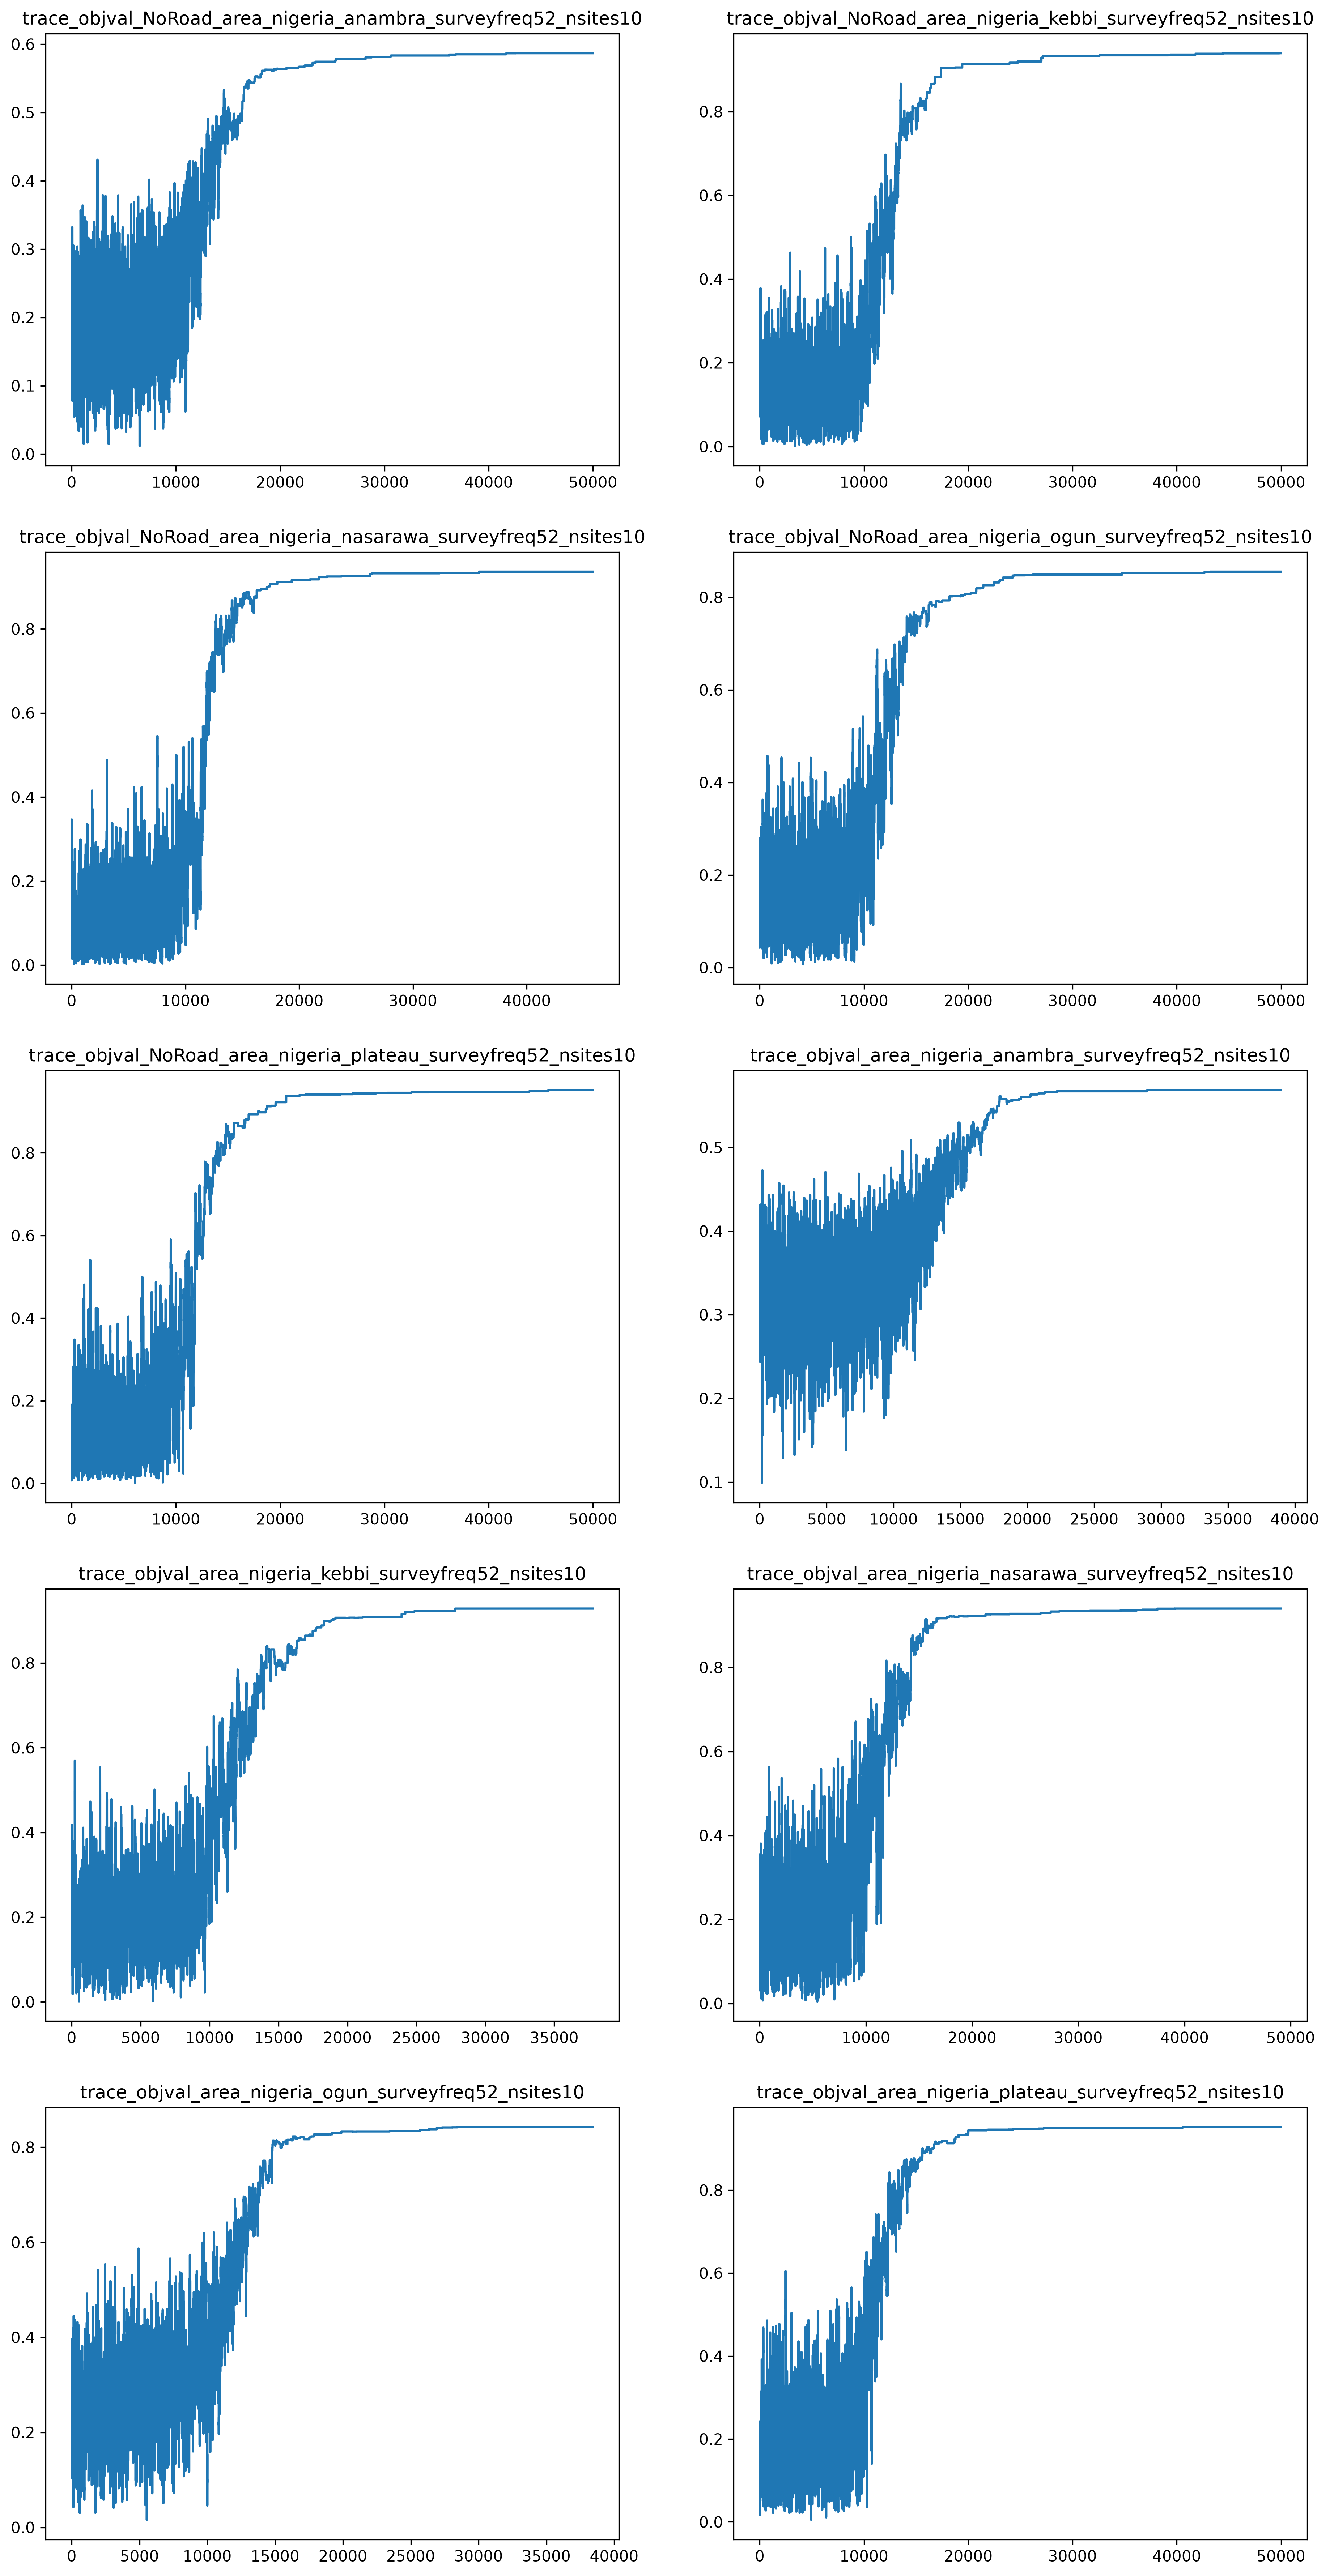

In [28]:
fig, axes = plt.subplots(5,2, figsize=(15, 30), dpi=300)
ax = axes.flatten()
for i, f in enumerate(filenames_trace):
    trace = trace_dict[f]
    title = f.replace('.joblib', '')
    ax[i].plot(trace)
    ax[i].set_title(title)

plt.savefig(os.path.join(cwd, 'Plots for new paper/trace_plots.png'), bbox_inches='tight')
plt.show()